In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [2]:
df = pd.read_csv('KO_CocaCola_Stock_Prices_1980_2026.csv')
print(df.head())
print(df.shape)

         Date    Open    High     Low   Close   Volume  Daily_Return_Pct  \
0  1980-01-02  0.1937  0.1944  0.1895  0.1895  3451200               NaN   
1  1980-01-03  0.1895  0.1951  0.1881  0.1944  3960000            2.5858   
2  1980-01-04  0.1944  0.1965  0.1937  0.1965  1694400            1.0802   
3  1980-01-07  0.1965  0.1972  0.1951  0.1958  4396800           -0.3562   
4  1980-01-08  0.1958  0.1979  0.1958  0.1972  3244800            0.7150   

   Daily_Range  MA_20  MA_50  ...  BB_Upper  BB_Lower  BB_Width  RSI_14  \
0       0.0049    NaN    NaN  ...       NaN       NaN       NaN     NaN   
1       0.0070    NaN    NaN  ...       NaN       NaN       NaN     NaN   
2       0.0028    NaN    NaN  ...       NaN       NaN       NaN     NaN   
3       0.0021    NaN    NaN  ...       NaN       NaN       NaN     NaN   
4       0.0021    NaN    NaN  ...       NaN       NaN       NaN     NaN   

   Volume_MA_20  Cumulative_Return_Pct  Year  Month  Quarter  Day_of_Week  
0           NaN 

In [3]:
# Converting Date & Time to ensure time-series sorting
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

In [4]:
# Features Selection
features = ['Close', 'RSI_14', 'MA_50', 'BB_Width', 'Daily_Return_Pct']
df_filtered = df[['Date'] + features].dropna()
data_values = df_filtered[features].values

In [5]:
# Data Normalization
# Neural networks are sensitive to scale.we 'SQUASH' values to 0 and 1
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data_values)

In [6]:
# Creating the time-step sequences
prediction_days = 60
x_train, y_train = [], []

In [7]:
for i in range(prediction_days, len(scaled_data)):
    # x_trained: The sequence of all features for the past 60 days
    x_train.append(scaled_data[i - prediction_days:i, :])
    # y_train: The actual 'Close' price we want the model to learn to predict
    y_train.append(scaled_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [8]:
# Designing the Neural Network
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])),# First layer = 60 days sequence
    Dropout(0.2), # drop out randomly 20%
    LSTM(units=50, return_sequences=False), # Second layer catches deeper pattern from the first layer
    Dropout(0.2),
    Dense(units=25), # condense them into single price prediction
    Dense(units=1)
])

In [9]:
model.compile(optimizer='adam', loss='mean_squared_error') # ADAM is popular optimizer that automatically adjust learning rate

In [10]:
# Training the Brain
train_size = int(len(x_train) * 0.8)
model.fit(x_train[:train_size], y_train[:train_size], epochs=15, batch_size=32)

Epoch 1/15
288/288 [==============================] - 136s 319ms/step - loss: 0.0011
Epoch 2/15
288/288 [==============================] - 95s 329ms/step - loss: 2.7033e-04
Epoch 3/15
288/288 [==============================] - 93s 324ms/step - loss: 2.0581e-04
Epoch 4/15
288/288 [==============================] - 94s 326ms/step - loss: 1.9163e-04
Epoch 5/15
288/288 [==============================] - 93s 324ms/step - loss: 1.7395e-04
Epoch 6/15
288/288 [==============================] - 94s 325ms/step - loss: 1.6625e-04
Epoch 7/15
288/288 [==============================] - 95s 330ms/step - loss: 1.5676e-04
Epoch 8/15
288/288 [==============================] - 98s 340ms/step - loss: 1.6248e-04
Epoch 9/15
288/288 [==============================] - 94s 327ms/step - loss: 1.7132e-04
Epoch 10/15
288/288 [==============================] - 96s 334ms/step - loss: 1.4770e-04
Epoch 11/15
288/288 [==============================] - 94s 328ms/step - loss: 1.5380e-04
Epoch 12/15
288/288 [============

In [11]:
# Generating Predictions
predictions = model.predict(x_train[train_size:])

72/72 [==============================] - 17s 123ms/step


In [16]:
# Converting back to real world price 'USD'
prediction_copy = np.zeros((len(predictions), len(features)))
prediction_copy [:, 0] = predictions.flatten()
predictions_final = scaler.inverse_transform(prediction_copy)[:, 0]

In [17]:
# Visualization
actual_price = df_filtered['Close'].values[train_size + prediction_days:]
dates = df_filtered['Date'].values[train_size + prediction_days:]

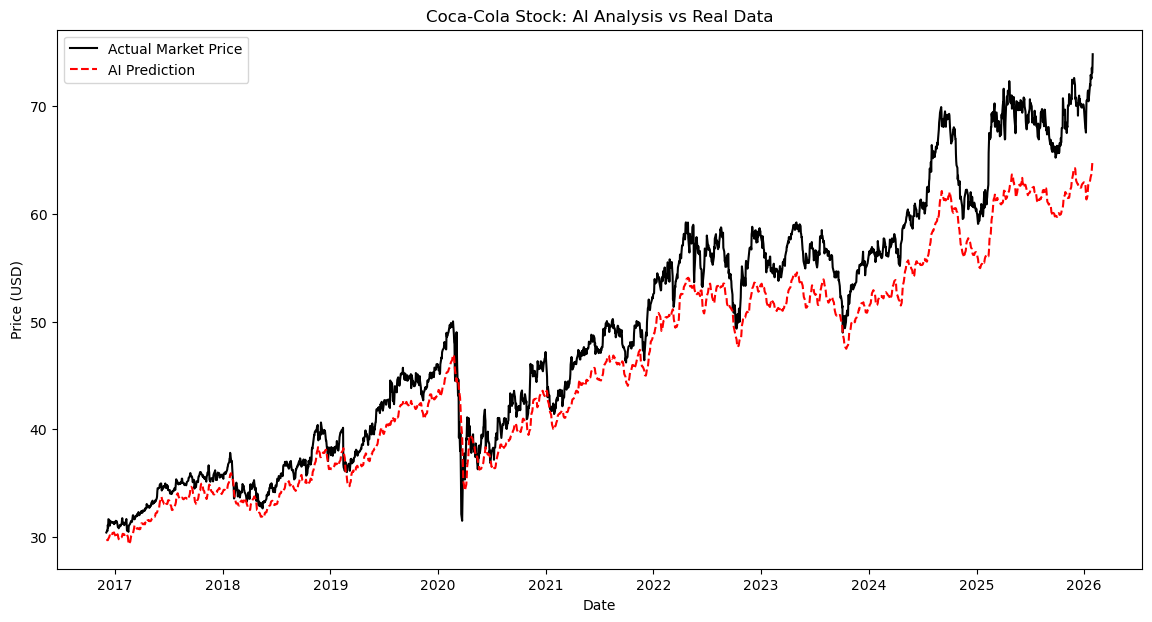

In [20]:
plt.figure(figsize=(14,7))
plt.plot(dates, actual_price, color='black', label='Actual Market Price')
plt.plot(dates, predictions_final, color='red', linestyle='--', label='AI Prediction')
plt.title('Coca-Cola Stock: AI Analysis vs Real Data')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [23]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(actual_price, predictions_final)
rmse = np.sqrt(mse)
print(f" The average error in price prediction is ${rmse:.2f}")

 The average error in price prediction is $3.91


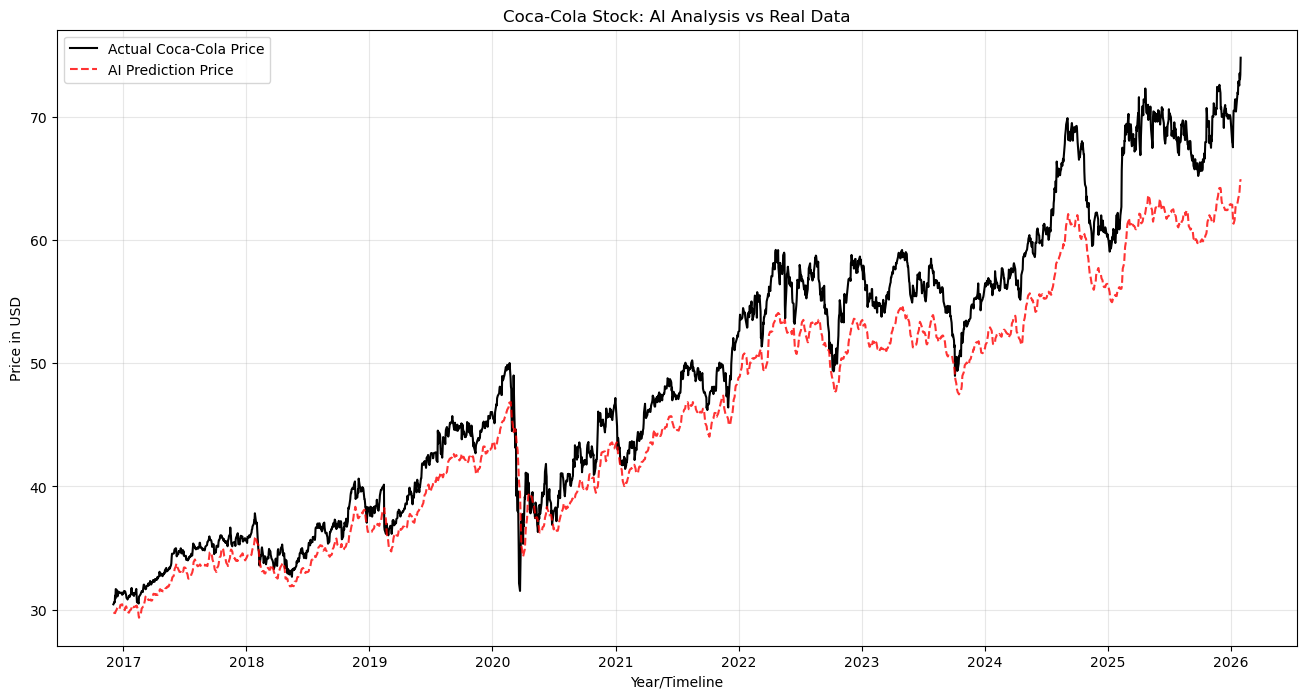

In [24]:
plt.figure(figsize=(16,8))
plt.plot(dates, actual_price, color='black', label='Actual Coca-Cola Price', linewidth=1.5)
plt.plot(dates, predictions_final, color='red', linestyle='--', label='AI Prediction Price', alpha=0.8)
plt.title('Coca-Cola Stock: AI Analysis vs Real Data')
plt.xlabel('Year/Timeline')
plt.ylabel('Price in USD')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()